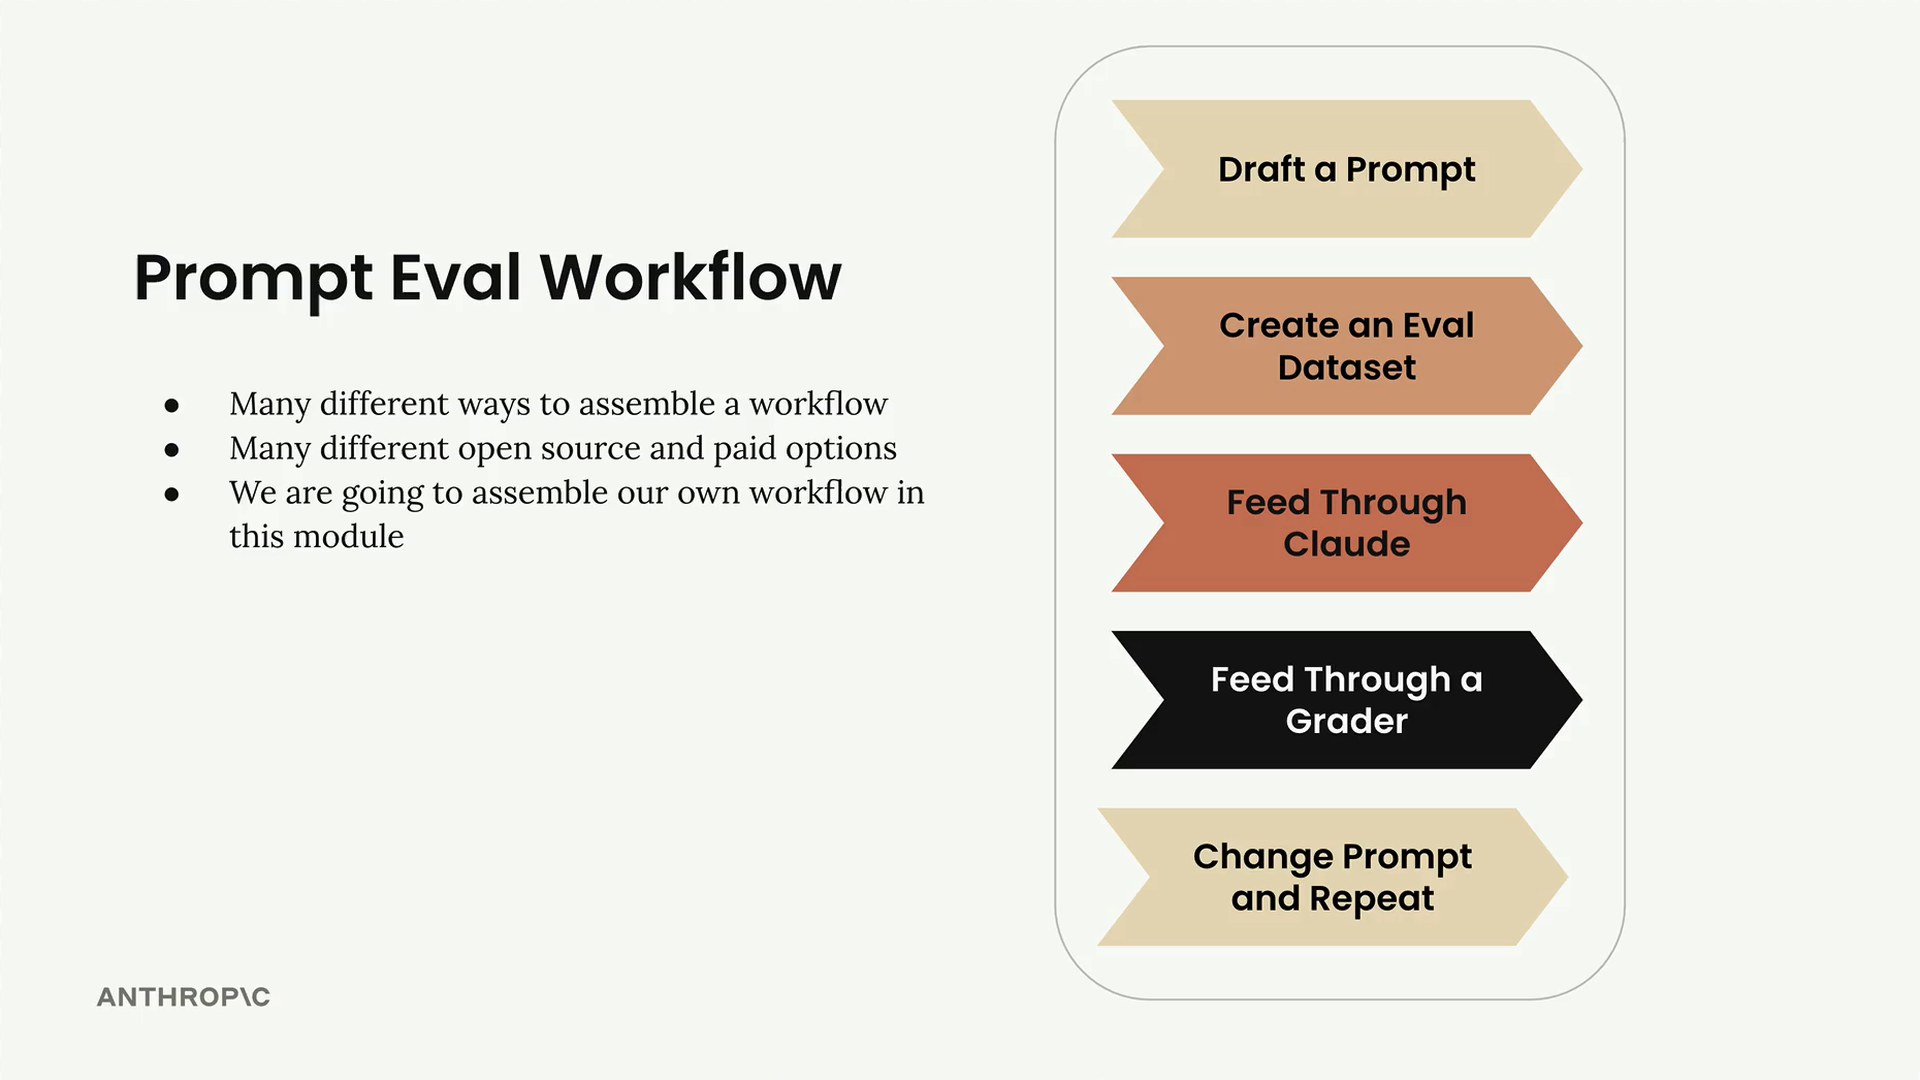

In [2]:
import boto3
import json
print(f"Boto3 version: {boto3.__version__}")
usage_history = []

Boto3 version: 1.43.85


In [3]:
region = "ap-south-1"
target_model_id = "anthropic.claude-haiku-4-5-20251001-v1:0"
# initialize a boto3 session with the specified region
session = boto3.Session(region_name=region)

bedrock = session.client("bedrock")
# list all inference profiles and filter for the one that matches the target model ID
profiles = bedrock.list_inference_profiles(
    typeEquals="SYSTEM_DEFINED"
)["inferenceProfileSummaries"]

matching_profiles = [
    profile
    for profile in profiles
    if any(
        target_model_id in model.get("modelArn", "")
        for model in profile.get("models", [])
    )
]

if not matching_profiles:
    raise RuntimeError(
        f"No inference profile for {target_model_id} is available in {region}."
    )

model_id = matching_profiles[0]["inferenceProfileId"]
client = session.client("bedrock-runtime")
print(f"Using inference profile: {model_id}")


Using inference profile: global.anthropic.claude-haiku-4-5-20251001-v1:0


In [4]:
def add_user_message(messages, text):
    messages.append({
        "role": "user",
        "content": [{"text": text}],
    })


def add_assistant_message(messages, text):
    messages.append({
        "role": "assistant",
        "content": [{"text": text}],
    })


def chat_with_model(messages, system=None, Temperature=1 , max_tokens=2000, stop_sequences=[]):
    params = {
        "modelId": model_id,
        "messages": messages,
        "inferenceConfig": {
            "temperature": Temperature,
            "maxTokens": max_tokens,
            "stopSequences": stop_sequences
        }}
    if system:
        params["system"] = [{"text": system}]
    response = client.converse(**params)
    return response["output"]["message"]["content"][0]["text"]





In [5]:
def generate_dataset():
    prompt =  """
Generate a evaluation dataset for a prompt evaluation. The dataset will be used to evaluate prompts
that generate Python, JSON, or Regex specifically for AWS-related tasks. Generate an array of JSON objects,
each representing task that requires Python, JSON, or a Regex to complete.

Example output:
```json
[
    {
        "task": "Description of task",
        "format": "json" or "python" or "regex",
        "solution_criteria": "Key criteria for evaluating the solution"
    },
    ...additional
]
```

* Focus on tasks that can be solved by writing a single Python function, a single JSON object, or a regular expression.
* Focus on tasks that do not require writing much code

Please generate 3 objects.
"""
    messages = []
    add_user_message(messages, prompt)
    add_assistant_message(messages, "```json") # adding the prefilled assistant message to give claud a start. it will now not generate the ```json in the output.
    text = chat_with_model(messages, stop_sequences=["```"]) # adding stop sequence to stop the model from generating the closing ``` in the output.
    return json.loads(text)

In [6]:
generate_dataset()

[{'task': 'Parse an AWS CloudFormation template and extract all resource logical IDs that are of type AWS::S3::Bucket',
  'format': 'python',
  'solution_criteria': 'Function should return a list of logical IDs for S3 bucket resources. Should handle nested structures and return an empty list if no S3 buckets are found.'},
 {'task': "Create a JSON policy document that allows an IAM user to perform GetObject and PutObject actions only on a specific S3 bucket named 'my-app-bucket'",
  'format': 'json',
  'solution_criteria': 'Valid IAM policy JSON with correct Principal, Action, Resource, and Effect fields. Should restrict actions to GetObject and PutObject only and limit to the specified bucket.'},
 {'task': 'Write a regular expression to validate AWS S3 bucket names according to AWS naming rules (lowercase letters, numbers, hyphens, 3-63 characters, cannot start/end with hyphen)',
  'format': 'regex',
  'solution_criteria': 'Regex should match valid S3 bucket names and reject invalid on

In [7]:
# now we need to save the dataset into a json file. We will save it into a file called prompt_evaluation_dataset.json
dataset = generate_dataset()
with open("prompt_evaluation_dataset.json", "w") as f:
    json.dump(dataset, f, indent=4)

In [15]:
# def run_prompt(test_case):
#     messages = []
#     prompt = test_case["task"]
#     add_user_message(messages, prompt)
#     response = chat_with_model(messages)
#     return response

def run_prompt(test_case):
    """Merges the prompt and test case input, then returns the result"""
    prompt = f"""
    Please solve the following task:
    
    {test_case["task"]}
    
    * Respond only with Python, JSON, or a plain Regex
    * Do not add any comments or commentary or explanation
    """
    
    system_prompt = "You are an experienced AWS engineer with a hyper focus on addressing corner cases"
    
    messages = []
    add_user_message(messages, prompt)
    add_assistant_message(messages, "```code")
    output = chat_with_model(messages, stop_sequences=["```"], system=system_prompt)
    return output


def run_test_case(test_case):
    output = run_prompt(test_case)
    # TODO: implement evaluation logic based on test_case["solution_criteria"]
    score = 10.0
    return {"output": output,
            "test_case": test_case,
            "score": score}
    
def run_eval(dataset):
    results = []
    for test_case in dataset:
        result = run_test_case(test_case)
        results.append(result)
    return results

In [23]:
import json
with open("prompt_evaluation_dataset.json", "r") as f:
    dataset = json.load(f)
print(dataset)

[{'task': 'Parse an AWS CloudFormation template and extract all resource logical IDs', 'format': 'python', 'solution_criteria': 'Function should accept a CloudFormation template (dict or JSON string) and return a list of all resource logical IDs from the Resources section'}, {'task': 'Create a JSON policy document that allows an IAM user to read and list objects from a specific S3 bucket', 'format': 'json', 'solution_criteria': "Valid IAM policy JSON with appropriate S3 actions (s3:GetObject, s3:ListBucket), resources specified for a bucket named 'my-bucket', and correct effect set to Allow"}, {'task': 'Validate AWS IAM usernames using a regular expression pattern', 'format': 'regex', 'solution_criteria': 'Regex pattern that matches valid IAM usernames (1-64 characters, alphanumeric plus +=,.@-) and rejects invalid ones like empty strings or names with spaces'}]


In [8]:
# run_eval(dataset)
t1 = dataset[0]
t1
output1 = run_prompt(t1)

In [16]:
# output2 = run_test_case(t1)
# output2

results = run_eval(dataset)
print(json.dumps(results, indent=4))

[
    {
        "output": "\nimport json\nimport sys\n\ndef extract_resource_logical_ids(template_str):\n    try:\n        template = json.loads(template_str)\n    except json.JSONDecodeError:\n        return []\n    \n    if not isinstance(template, dict):\n        return []\n    \n    resources = template.get('Resources', {})\n    \n    if not isinstance(resources, dict):\n        return []\n    \n    return list(resources.keys())\n\nif __name__ == '__main__':\n    template_input = sys.stdin.read()\n    logical_ids = extract_resource_logical_ids(template_input)\n    print(json.dumps(logical_ids, indent=2))\n",
        "test_case": {
            "task": "Parse an AWS CloudFormation template and extract all resource logical IDs",
            "format": "python",
            "solution_criteria": "Function should accept a CloudFormation template (dict or JSON string) and return a list of all resource logical IDs from the Resources section"
        },
        "score": 10.0
    },
    {
   

### code based grading

In [17]:
import ast
import json
import re

def validate_json(json_string):
    try:
        json.loads(json_string.strip())
        return 10
    except json.JSONDecodeError:
        return 0

def validate_python(python_string):
    try:
        ast.parse(python_string.strip())
        return 10
    except SyntaxError:
        return 0

def validate_regex(regex_string):
    try:
        re.compile(regex_string.strip())
        return 10
    except re.error:
        return 0

def grade_format(reponse, test_case):
    format_type = test_case["format"]
    if format_type == "json":
        return validate_json(reponse)
    elif format_type == "python":
        return validate_python(reponse)
    elif format_type == "regex":
        return validate_regex(reponse)
    else:
        raise ValueError(f"Unknown format type: {format_type}")

In [ ]:
def grade_by_model(test_case, output):
    eval_prompt = f"""
You are an expert AWS code reviewer. Your task is to evaluate the following AI-generated solution.

Original Task:
<task>
{test_case["task"]}
</task>

Solution to Evaluate:
<solution>
{output}
</solution>

Criteria you should use to evaluate the solution:
<criteria>
{test_case["solution_criteria"]}
</criteria>

Output Format
Provide your evaluation as a structured JSON object with the following fields, in this specific order:
- "strengths": An array of 1-3 key strengths
- "weaknesses": An array of 1-3 key areas for improvement
- "reasoning": A concise explanation of your overall assessment
- "score": A number between 1-10

Respond with JSON. Keep your response concise and direct.
Example response shape:
{{
    "strengths": string[],
    "weaknesses": string[],
    "reasoning": string,
    "score": number
}}
    """

    messages = []
    add_user_message(messages, eval_prompt)
    add_assistant_message(messages, "```json")
    eval_text = chat_with_model(messages, stop_sequences=["```"])
    return json.loads(eval_text)


## Grade by model function with solution criteria included. That results in better grading


In [ ]:
def run_test_case(test_case):
    """Calls run_prompt, then grades the result"""
    output = run_prompt(test_case)

    model_grade = grade_by_model(test_case, output)
    model_score = model_grade["score"]
    reasoning = model_grade["reasoning"]

    format_score = grade_format(output, test_case)

    model_score = (model_score + format_score) / 2

    return {
        "output": output,
        "test_case": test_case,
        "score": model_score,
        "reasoning": reasoning,
    }
    

In [32]:
from statistics import mean


def run_eval(dataset):
    """Loads the dataset and calls run_test_case with each case"""
    results = []

    for test_case in dataset:
        result = run_test_case(test_case)
        results.append(result)

    average_score = mean([result["score"] for result in results])
    print(f"Average score: {average_score}")

    return results

In [33]:
test_results = run_eval(dataset)
print(json.dumps(test_results, indent=4))

Average score: 6.5
[
    {
        "output": "\nimport json\nimport sys\n\ndef extract_resource_ids(template_content):\n    try:\n        template = json.loads(template_content)\n        if isinstance(template, dict) and \"Resources\" in template:\n            return list(template[\"Resources\"].keys())\n        return []\n    except json.JSONDecodeError:\n        return []\n\nif __name__ == \"__main__\":\n    template_input = sys.stdin.read()\n    resource_ids = extract_resource_ids(template_input)\n    print(json.dumps(resource_ids))\n",
        "test_case": {
            "task": "Parse an AWS CloudFormation template and extract all resource logical IDs",
            "format": "python",
            "solution_criteria": "Function should accept a CloudFormation template (dict or JSON string) and return a list of all resource logical IDs from the Resources section"
        },
        "score": 7.5,
        "reasoning": "The solution successfully handles the basic case of parsing JSON Clo

In [ ]:
import markdown
from bs4 import BeautifulSoup

def extract_code(text):
    html = markdown.markdown(text, extensions=["fenced_code"])
    soup = BeautifulSoup(html, "html.parser")
    return "\n\n".join(block.get_text() for block in soup.find_all("code"))



NameError: name 'output' is not defined

In [26]:
from IPython.display import display, Markdown



In [34]:
# import Markdown
test_results = run_eval(dataset)
text = test_results[2]["output"]
# display(Markdown(text.replace("\n", "<br>")))
print(extract_code(text))

Average score: 6.333333333333333
Valid characters: a-z, A-Z, 0-9, and these special characters: +=,.@-_
Length: 1-128 characters
"""
pattern = r'^[a-zA-Z0-9+=,.@\-_]{1,128}$'
return bool(re.match(pattern, username))


for username, expected in test_cases:
    result = validate_iam_username(username)
    status = "✓" if result == expected else "✗"
    print(f"{status} '{username}': {result} (expected {expected})")



#### NOW: How can we update our prompt and get a better score for each of the test casses